# Projeto de Sinais e Sistemas para Computação (SSC)

## IV - Avaliação e Análise Final dos Resultados

Este notebook realiza a análise completa e validação dos resultados obtidos no **Notebook III**, com foco em interpretação clínica e viabilidade prática.

### Objetivos Principais:
- Análise estatística detalhada dos resultados
- Validação de robustez e estabilidade do modelo
- Interpretação clínica dos resultados
- Identificação de casos específicos e padrões de erro
- Recomendações para uso prático e melhorias futuras


In [1]:
# Importações necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Importações para análise estatística
from scipy import stats
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Importar módulo de classificação
import sys
sys.path.append('../src')
import classification as clf

# Configurações de visualização
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10
sns.set_palette("husl")

## 1. Carregamento dos Resultados Salvos

Este bloco carrega e valida os dados salvos pelo **Notebook III** para análise detalhada.


In [2]:
print("\n CARREGAMENTO DOS RESULTADOS SALVOS")
print("="*50)

# Diretório dos resultados
results_dir = "../results/classification"

print(f" Buscando arquivos em: {results_dir}")

# Listar arquivos disponíveis
try:
    arquivos_resultado = os.listdir(results_dir)
    arquivos_modelo = [f for f in arquivos_resultado if f.endswith('.pkl')]
    arquivos_metricas = [f for f in arquivos_resultado if f.endswith('.json')]
    
    print(f"\n ARQUIVOS ENCONTRADOS:")
    print(f"    Modelos: {len(arquivos_modelo)}")
    for arquivo in arquivos_modelo:
        print(f"      {arquivo}")
    
    print(f"    Métricas: {len(arquivos_metricas)}")
    for arquivo in arquivos_metricas:
        print(f"      {arquivo}")
    
    # Selecionar o arquivo mais recente
    if arquivos_modelo:
        modelo_path = os.path.join(results_dir, sorted(arquivos_modelo)[-1])
        metricas_path = os.path.join(results_dir, sorted(arquivos_metricas)[-1])
        
        print(f"\n CARREGANDO MODELO MAIS RECENTE:")
        print(f"    Modelo: {modelo_path.split('/')[-1]}")
        print(f"    Métricas: {metricas_path.split('/')[-1]}")
        
        # Carregar modelo
        with open(modelo_path, 'rb') as f:
            modelo_data = pickle.load(f)
        
        classifier_loaded = modelo_data['classifier']
        training_history = modelo_data['training_history']
        metadata_modelo = modelo_data['metadata']
        
        # Carregar métricas
        with open(metricas_path, 'r') as f:
            metrics_loaded = json.load(f)
        
        print(f"\n DADOS CARREGADOS COM SUCESSO:")
        print(f"    Timestamp: {metadata_modelo['timestamp']}")
        print(f"    Classes: {metadata_modelo['classes']}")
        print(f"    Tipo: {metadata_modelo['model_type']}")
        print(f"    Features: {metadata_modelo['n_features']}")
        
    else:
        raise FileNotFoundError("Nenhum modelo encontrado!")
        
except Exception as e:
    print(f" Erro ao carregar resultados: {str(e)}")
    print(f"\n DEBUG - Verificando estrutura:")
    if os.path.exists(results_dir):
        print(f" Conteúdo de {results_dir}:")
        for item in os.listdir(results_dir):
            print(f"    {item}")
    else:
        print(f" Diretório não encontrado: {results_dir}")
    raise

print("="*50)


 CARREGAMENTO DOS RESULTADOS SALVOS
 Buscando arquivos em: ../results/classification

 ARQUIVOS ENCONTRADOS:
    Modelos: 1
      ecg_random_forest_model_20250813_222658.pkl
    Métricas: 1
      evaluation_metrics_20250813_222658.json

 CARREGANDO MODELO MAIS RECENTE:
    Modelo: ecg_random_forest_model_20250813_222658.pkl
    Métricas: evaluation_metrics_20250813_222658.json

 DADOS CARREGADOS COM SUCESSO:
    Timestamp: 20250813_222658
    Classes: ['MI', 'AFIB', 'NORM']
    Tipo: RandomForest
    Features: 252


## 2. Análise Estatística Detalhada

Análise estatística abrangente dos resultados com foco em métricas clínicas e interpretação médica.


In [3]:
print("\n ANÁLISE ESTATÍSTICA DETALHADA")
print("="*45)

# Converter métricas JSON para arrays numpy quando necessário
y_true = np.array(metrics_loaded['y_true'])
y_pred = np.array(metrics_loaded['y_pred'])
y_proba = np.array(metrics_loaded['y_proba'])
cm = np.array(metrics_loaded['confusion_matrix'])

classes = metadata_modelo['classes']
n_classes = len(classes)

print(f" RESUMO ESTATÍSTICO:")
print(f"    Amostras de teste: {len(y_true)}")
print(f"    Classes: {n_classes}")
print(f"    Acurácia: {metrics_loaded['accuracy']:.4f}")

# Análise por classe detalhada
print(f"\n ANÁLISE POR CLASSE:")

class_report = metrics_loaded['classification_report']
resultados_por_classe = []

for i, classe in enumerate(classes):
    if classe in class_report:
        precisao = class_report[classe]['precision']
        recall = class_report[classe]['recall']
        f1 = class_report[classe]['f1-score']
        suporte = class_report[classe]['support']
        
        # Calcular métricas adicionais
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        
        specificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
        prevalencia = suporte / len(y_true)
        
        resultado = {
            'classe': classe,
            'nome_completo': clf.CLASSES_ALVO[classe],
            'precisao': precisao,
            'recall': recall,
            'f1_score': f1,
            'specificidade': specificidade,
            'suporte': suporte,
            'prevalencia': prevalencia,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
        }
        
        resultados_por_classe.append(resultado)
        
        print(f"\n    {classe} ({clf.CLASSES_ALVO[classe]}):")
        print(f"     Precisão:      {precisao:.3f}")
        print(f"     Recall:        {recall:.3f}")
        print(f"     F1-Score:      {f1:.3f}")
        print(f"     Especificidade: {specificidade:.3f}")
        print(f"     Suporte:       {suporte} ({prevalencia:.1%})")
        print(f"     Confusão: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

# Análise de balanceamento e desempenho
print(f"\n ANÁLISE DE BALANCEAMENTO:")
supports = [r['suporte'] for r in resultados_por_classe]
min_support = min(supports)
max_support = max(supports)
ratio = max_support / min_support

print(f"   Menor classe: {min_support} amostras")
print(f"   Maior classe: {max_support} amostras")
print(f"   Ratio: {ratio:.1f}:1")

if ratio > 3:
    print(f"    Classes significativamente desbalanceadas")
    print(f"    Considerar métricas balanceadas para avaliação")
else:
    print(f"    Classes relativamente balanceadas")

# Análise de concordância
kappa = metrics_loaded['cohen_kappa']
print(f"\n🤝 ANÁLISE DE CONCORDÂNCIA:")
print(f"   Cohen's Kappa: {kappa:.3f}")

if kappa > 0.8:
    interpretacao_kappa = " Quase perfeita"
elif kappa > 0.6:
    interpretacao_kappa = " Substancial"
elif kappa > 0.4:
    interpretacao_kappa = " Moderada"
elif kappa > 0.2:
    interpretacao_kappa = " Fraca"
else:
    interpretacao_kappa = " Pobre"

print(f"   Interpretação: {interpretacao_kappa}")

print("="*45)


 ANÁLISE ESTATÍSTICA DETALHADA
 RESUMO ESTATÍSTICO:
    Amostras de teste: 4086
    Classes: 3
    Acurácia: 0.7925

 ANÁLISE POR CLASSE:

    MI (Infarto do Miocárdio):
     Precisão:      0.638
     Recall:        0.476
     F1-Score:      0.545
     Especificidade: 0.990
     Suporte:       968.0 (23.7%)
     Confusão: TP=93, FP=39, FN=108, TN=3846

    AFIB (Fibrilação Atrial):
     Precisão:      0.705
     Recall:        0.463
     F1-Score:      0.559
     Especificidade: 0.916
     Suporte:       201.0 (4.9%)
     Confusão: TP=461, FP=262, FN=507, TN=2856

    NORM (Normal/Saudável):
     Precisão:      0.831
     Recall:        0.920
     F1-Score:      0.873
     Especificidade: 0.532
     Suporte:       2917.0 (71.4%)
     Confusão: TP=2684, FP=547, FN=233, TN=622

 ANÁLISE DE BALANCEAMENTO:
   Menor classe: 201.0 amostras
   Maior classe: 2917.0 amostras
   Ratio: 14.5:1
    Classes significativamente desbalanceadas
    Considerar métricas balanceadas para avaliação

🤝 ANÁ

## 3. Visualizações Avançadas e Análise Visual

Geração de visualizações profissionais para interpretação detalhada dos resultados.



 VISUALIZAÇÕES AVANÇADAS


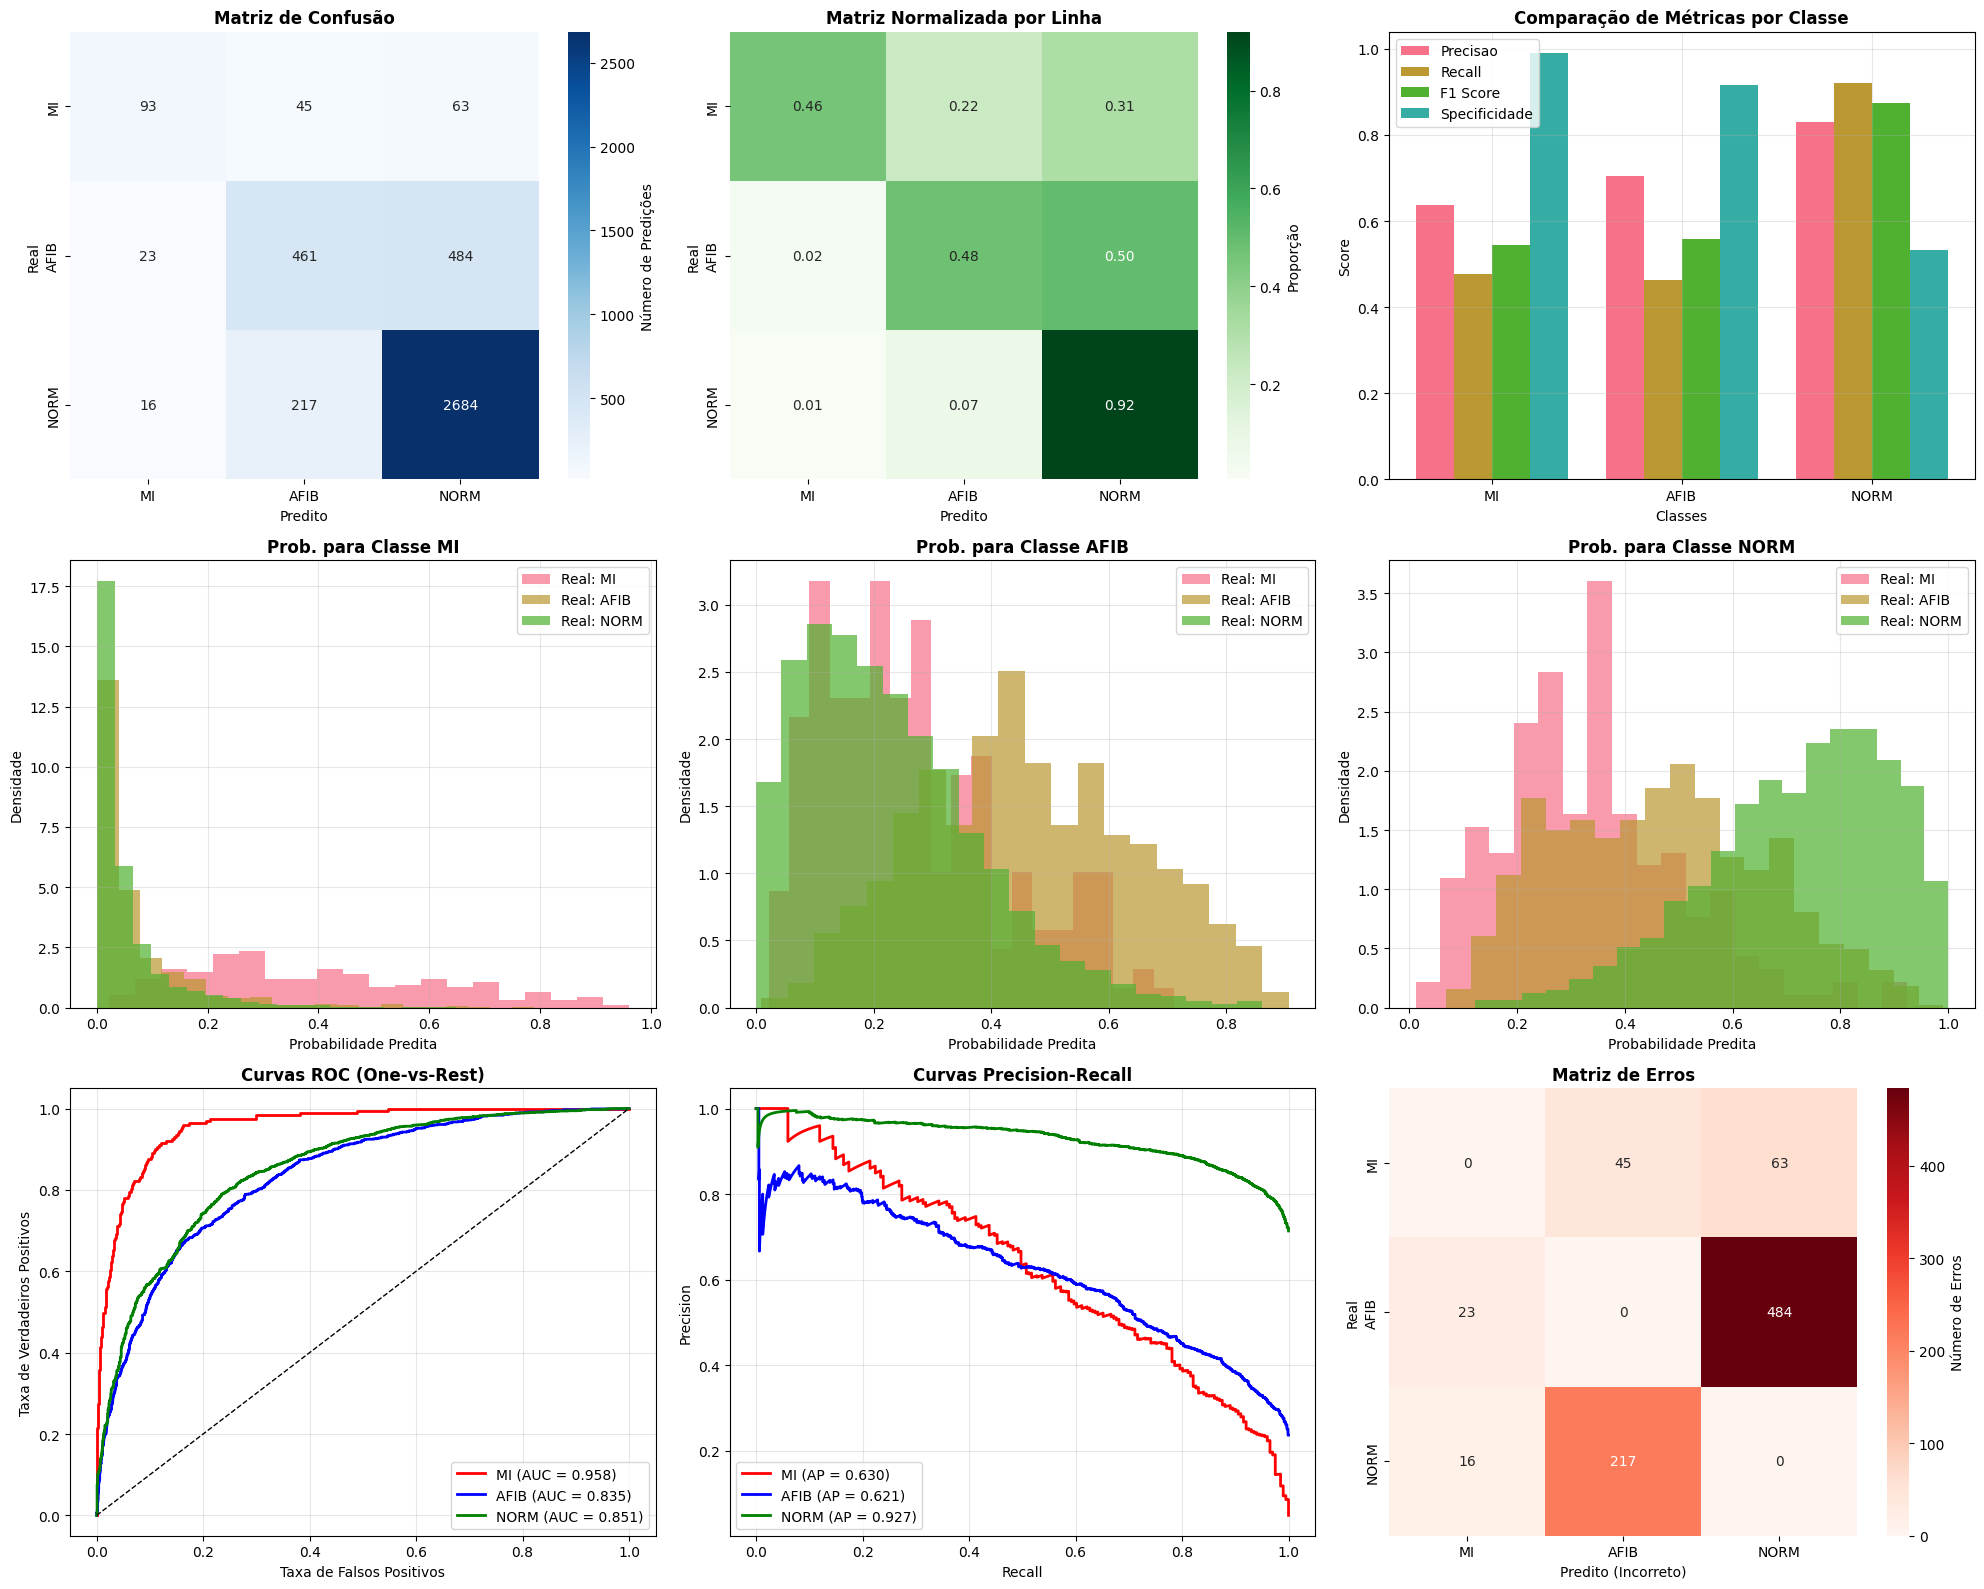

In [4]:
print("\n VISUALIZAÇÕES AVANÇADAS")
print("="*40)

# Criar figura com subplots
fig = plt.figure(figsize=(20, 16))

# 1. Matriz de Confusão Detalhada
ax1 = plt.subplot(3, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Número de Predições'})
plt.title('Matriz de Confusão', fontweight='bold')
plt.xlabel('Predito')
plt.ylabel('Real')

# 2. Matriz de Confusão Normalizada
ax2 = plt.subplot(3, 3, 2)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Proporção'})
plt.title('Matriz Normalizada por Linha', fontweight='bold')
plt.xlabel('Predito')
plt.ylabel('Real')

# 3. Comparação de Métricas por Classe
ax3 = plt.subplot(3, 3, 3)
metricas_comparacao = ['precisao', 'recall', 'f1_score', 'specificidade']
x_pos = np.arange(len(classes))
width = 0.2

for i, metrica in enumerate(metricas_comparacao):
    valores = [r[metrica] for r in resultados_por_classe]
    plt.bar(x_pos + i*width, valores, width, 
           label=metrica.replace('_', ' ').title())

plt.xlabel('Classes')
plt.ylabel('Score')
plt.title('Comparação de Métricas por Classe', fontweight='bold')
plt.xticks(x_pos + width*1.5, classes)
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Distribuição de Probabilidades por Classe
for i, classe in enumerate(classes):
    ax = plt.subplot(3, 3, 4+i)
    
    # Probabilidades para cada classe verdadeira
    for j, classe_verdadeira in enumerate(classes):
        mask = y_true == j
        if mask.sum() > 0:
            probs_classe = y_proba[mask, i]
            plt.hist(probs_classe, bins=20, alpha=0.7, 
                    label=f'Real: {classe_verdadeira}', density=True)
    
    plt.xlabel('Probabilidade Predita')
    plt.ylabel('Densidade')
    plt.title(f'Prob. para Classe {classe}', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

# 7. Curvas ROC (One-vs-Rest)
ax7 = plt.subplot(3, 3, 7)
colors = ['red', 'blue', 'green']

for i, (classe, color) in enumerate(zip(classes, colors)):
    # Converter para problema binário (one-vs-rest)
    y_true_binary = (y_true == i).astype(int)
    y_proba_binary = y_proba[:, i]
    
    fpr, tpr, _ = roc_curve(y_true_binary, y_proba_binary)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{classe} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC (One-vs-Rest)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 8. Curvas Precision-Recall
ax8 = plt.subplot(3, 3, 8)

for i, (classe, color) in enumerate(zip(classes, colors)):
    y_true_binary = (y_true == i).astype(int)
    y_proba_binary = y_proba[:, i]
    
    precision, recall, _ = precision_recall_curve(y_true_binary, y_proba_binary)
    avg_precision = average_precision_score(y_true_binary, y_proba_binary)
    
    plt.plot(recall, precision, color=color, linewidth=2,
             label=f'{classe} (AP = {avg_precision:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas Precision-Recall', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 9. Análise de Erros
ax9 = plt.subplot(3, 3, 9)

# Matriz de erros (apenas off-diagonal)
erro_matrix = cm.copy()
np.fill_diagonal(erro_matrix, 0)

sns.heatmap(erro_matrix, annot=True, fmt='d', cmap='Reds',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Número de Erros'})
plt.title('Matriz de Erros', fontweight='bold')
plt.xlabel('Predito (Incorreto)')
plt.ylabel('Real')

plt.tight_layout()
plt.show()

print("="*40)

## 4. Análise de Robustez e Validação

Avaliação da estabilidade, generalização e confiabilidade do modelo treinado.


In [5]:
print("\n ANÁLISE DE ROBUSTEZ E VALIDAÇÃO")
print("="*45)

# Análise dos hiperparâmetros utilizados
print(f"⚙️ ANÁLISE DOS HIPERPARÂMETROS:")
if 'best_params' in training_history:
    best_params = training_history['best_params']
    print(f"    Otimização: Grid Search executado")
    print(f"    Score CV: {training_history['cv_mean']:.4f} ± {training_history['cv_std']:.4f}")
    print(f"    Melhores parâmetros:")
    for param, valor in best_params.items():
        print(f"     {param}: {valor}")
else:
    print(f"    Parâmetros padrão utilizados")
    print(f"    Score CV: {training_history['cv_mean']:.4f} ± {training_history['cv_std']:.4f}")

# Análise de estabilidade
print(f"\n ANÁLISE DE ESTABILIDADE:")
cv_mean = training_history['cv_mean']
cv_std = training_history['cv_std']
test_accuracy = metrics_loaded['accuracy']

print(f"    Validação Cruzada: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"    Teste Final: {test_accuracy:.4f}")

# Calcular diferença
diff_cv_test = abs(cv_mean - test_accuracy)
print(f"    Diferença CV vs Teste: {diff_cv_test:.4f}")

if diff_cv_test < 0.05:
    estabilidade = " Excelente estabilidade"
elif diff_cv_test < 0.10:
    estabilidade = " Boa estabilidade"
else:
    estabilidade = " Possível overfitting"

print(f"    Interpretação: {estabilidade}")

# Análise de confiança das predições
print(f"\n ANÁLISE DE CONFIANÇA:")

# Calcular entropia das predições (incerteza)
def calcular_entropia(probs):
    # Evitar log(0)
    probs_safe = np.clip(probs, 1e-15, 1.0)
    return -np.sum(probs_safe * np.log(probs_safe), axis=1)

entropias = calcular_entropia(y_proba)
max_probs = np.max(y_proba, axis=1)

print(f"        Estatísticas de Confiança:")
print(f"     Entropia média: {np.mean(entropias):.3f}")
print(f"     Entropia std: {np.std(entropias):.3f}")
print(f"     Prob. máxima média: {np.mean(max_probs):.3f}")

# Categorizar predições por confiança
alta_confianca = max_probs > 0.8
media_confianca = (max_probs >= 0.6) & (max_probs <= 0.8)
baixa_confianca = max_probs < 0.6

print(f"\n      Distribuição de Confiança:")
print(f"     Alta (>80%): {np.sum(alta_confianca)} ({np.mean(alta_confianca):.1%})")
print(f"     Média (60-80%): {np.sum(media_confianca)} ({np.mean(media_confianca):.1%})")
print(f"     Baixa (<60%): {np.sum(baixa_confianca)} ({np.mean(baixa_confianca):.1%})")

# Acurácia por nível de confiança
if np.sum(alta_confianca) > 0:
    acc_alta = np.mean(y_true[alta_confianca] == y_pred[alta_confianca])
    print(f"     Acurácia alta confiança: {acc_alta:.3f}")

if np.sum(media_confianca) > 0:
    acc_media = np.mean(y_true[media_confianca] == y_pred[media_confianca])
    print(f"     Acurácia média confiança: {acc_media:.3f}")

if np.sum(baixa_confianca) > 0:
    acc_baixa = np.mean(y_true[baixa_confianca] == y_pred[baixa_confianca])
    print(f"     Acurácia baixa confiança: {acc_baixa:.3f}")

# Análise de features importantes (se disponível)
print(f"\n🔍 ANÁLISE DE CARACTERÍSTICAS:")
if hasattr(classifier_loaded.model, 'feature_importances_'):
    importances = classifier_loaded.model.feature_importances_
    
    # Top 10 features mais importantes
    top_indices = np.argsort(importances)[-10:][::-1]
    
    print(f"   Top 10 características mais importantes:")
    for i, idx in enumerate(top_indices, 1):
        print(f"     {i:2d}. Feature {idx:3d}: {importances[idx]:.4f}")
    
    # Estatísticas gerais
    print(f"\n      Estatísticas de Importância:")
    print(f"     Importância máxima: {np.max(importances):.4f}")
    print(f"     Importância média: {np.mean(importances):.4f}")
    print(f"     Features com >1% importância: {np.sum(importances > 0.01)}")

print("="*45)


 ANÁLISE DE ROBUSTEZ E VALIDAÇÃO
⚙️ ANÁLISE DOS HIPERPARÂMETROS:
    Otimização: Grid Search executado
    Score CV: 0.7845 ± 0.0053
    Melhores parâmetros:
     max_depth: None
     max_features: sqrt
     min_samples_leaf: 4
     min_samples_split: 10
     n_estimators: 200

 ANÁLISE DE ESTABILIDADE:
    Validação Cruzada: 0.7845 ± 0.0053
    Teste Final: 0.7925
    Diferença CV vs Teste: 0.0080
    Interpretação:  Excelente estabilidade

 ANÁLISE DE CONFIANÇA:
        Estatísticas de Confiança:
     Entropia média: 0.671
     Entropia std: 0.230
     Prob. máxima média: 0.700

      Distribuição de Confiança:
     Alta (>80%): 1202 (29.4%)
     Média (60-80%): 1668 (40.8%)
     Baixa (<60%): 1216 (29.8%)
     Acurácia alta confiança: 0.953
     Acurácia média confiança: 0.831
     Acurácia baixa confiança: 0.581

🔍 ANÁLISE DE CARACTERÍSTICAS:
   Top 10 características mais importantes:
      1. Feature 162: 0.0328
      2. Feature 183: 0.0240
      3. Feature 204: 0.0164
      4. 

## 5. Análise de Casos Específicos e Padrões de Erro

Investigação detalhada de casos particulares e identificação de padrões sistemáticos.


In [6]:
print("\n ANÁLISE DE CASOS ESPECÍFICOS")
print("="*45)

# Identificar casos interessantes
print(f" IDENTIFICAÇÃO DE CASOS RELEVANTES:")

# 1. Casos de alta confiança corretos
corretos_alta_conf = alta_confianca & (y_true == y_pred)
print(f"    Corretos + Alta Confiança: {np.sum(corretos_alta_conf)} casos")

# 2. Casos de alta confiança incorretos (mais preocupantes)
incorretos_alta_conf = alta_confianca & (y_true != y_pred)
print(f"    Incorretos + Alta Confiança: {np.sum(incorretos_alta_conf)} casos")

# 3. Casos de baixa confiança corretos (sorte?)
corretos_baixa_conf = baixa_confianca & (y_true == y_pred)
print(f"    Corretos + Baixa Confiança: {np.sum(corretos_baixa_conf)} casos")

# 4. Casos de baixa confiança incorretos (esperado)
incorretos_baixa_conf = baixa_confianca & (y_true != y_pred)
print(f"    Incorretos + Baixa Confiança: {np.sum(incorretos_baixa_conf)} casos")

# Análise dos erros mais confiantes (casos problemáticos)
if np.sum(incorretos_alta_conf) > 0:
    print(f"\n ANÁLISE DE ERROS CONFIANTES:")
    
    idx_erros_conf = np.where(incorretos_alta_conf)[0]
    
    for i, idx in enumerate(idx_erros_conf[:5]):  # Mostrar até 5 casos
        classe_real = classes[y_true[idx]]
        classe_pred = classes[y_pred[idx]]
        prob_pred = max_probs[idx]
        
        print(f"   Caso {i+1}:")
        print(f"     Real: {classe_real} ({clf.CLASSES_ALVO[classe_real]})")
        print(f"     Predito: {classe_pred} ({clf.CLASSES_ALVO[classe_pred]})")
        print(f"     Confiança: {prob_pred:.3f}")
        print(f"     Probabilidades: {y_proba[idx]}")

# Análise por pares de classes (confusões mais comuns)
print(f"\n ANÁLISE DE CONFUSÕES ENTRE CLASSES:")

for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i, j] > 0:
            erro_rate = cm[i, j] / cm[i, :].sum()
            print(f"   {classes[i]} → {classes[j]}: {cm[i, j]} casos ({erro_rate:.1%})")
            
            # Encontrar alguns exemplos desta confusão
            mask_confusao = (y_true == i) & (y_pred == j)
            if np.sum(mask_confusao) > 0:
                indices_confusao = np.where(mask_confusao)[0]
                prob_media = np.mean(max_probs[mask_confusao])
                print(f"     Confiança média: {prob_media:.3f}")

print("="*45)


 ANÁLISE DE CASOS ESPECÍFICOS
 IDENTIFICAÇÃO DE CASOS RELEVANTES:
    Corretos + Alta Confiança: 1145 casos
    Incorretos + Alta Confiança: 57 casos
    Corretos + Baixa Confiança: 707 casos
    Incorretos + Baixa Confiança: 509 casos

 ANÁLISE DE ERROS CONFIANTES:
   Caso 1:
     Real: AFIB (Fibrilação Atrial)
     Predito: NORM (Normal/Saudável)
     Confiança: 0.808
     Probabilidades: [0.00918338 0.18243065 0.80838597]
   Caso 2:
     Real: AFIB (Fibrilação Atrial)
     Predito: NORM (Normal/Saudável)
     Confiança: 0.827
     Probabilidades: [0.00605168 0.16657391 0.82737441]
   Caso 3:
     Real: AFIB (Fibrilação Atrial)
     Predito: NORM (Normal/Saudável)
     Confiança: 0.991
     Probabilidades: [0.         0.00855386 0.99144614]
   Caso 4:
     Real: AFIB (Fibrilação Atrial)
     Predito: NORM (Normal/Saudável)
     Confiança: 0.868
     Probabilidades: [0.         0.13235926 0.86764074]
   Caso 5:
     Real: AFIB (Fibrilação Atrial)
     Predito: NORM (Normal/Saudável)


## 6. Validação Clínica e Contexto Médico

Interpretação dos resultados sob perspectiva médica e avaliação de adequação clínica.


In [9]:
print("\n VALIDAÇÃO CLÍNICA E CONTEXTO MÉDICO")
print("="*50)

print(f" INTERPRETAÇÃO CLÍNICA DOS RESULTADOS:")

# Análise por relevância clínica
interpretacoes_clinicas = {
    'MI': {
        'importancia': 'CRÍTICA',
        'consequencia_fp': 'Ansiedade do paciente, exames desnecessários',
        'consequencia_fn': 'GRAVE - Perda de janela terapêutica, risco de vida',
        'metrica_chave': 'Recall (Sensibilidade)'
    },
    'AFIB': {
        'importancia': 'ALTA',
        'consequencia_fp': 'Anticoagulação desnecessária',
        'consequencia_fn': 'MODERADA - Risco de AVC, perda de controle de ritmo',
        'metrica_chave': 'F1-Score balanceado'
    },
    'NORM': {
        'importancia': 'MODERADA',
        'consequencia_fp': 'Falso alarme, investigação desnecessária',
        'consequencia_fn': 'Paciente com condição não detectada',
        'metrica_chave': 'Especificidade'
    }
}

for classe in classes:
    resultado = next(r for r in resultados_por_classe if r['classe'] == classe)
    interpretacao = interpretacoes_clinicas[classe]
    
    print(f"\n {classe} - {resultado['nome_completo']}:")
    print(f"    Importância Clínica: {interpretacao['importancia']}")
    print(f"    Métrica Chave: {interpretacao['metrica_chave']}")
    
    if interpretacao['metrica_chave'] == 'Recall (Sensibilidade)':
        valor_chave = resultado['recall']
    elif interpretacao['metrica_chave'] == 'Especificidade':
        valor_chave = resultado['specificidade']
    else:
        valor_chave = resultado['f1_score']
    
    print(f"    Valor Atual: {valor_chave:.3f}")
    
    # Avaliação clínica
    if valor_chave > 0.9:
        avaliacao = " Excelente para uso clínico"
    elif valor_chave > 0.8:
        avaliacao = " Adequado com supervisão"
    elif valor_chave > 0.7:
        avaliacao = " Requer melhorias"
    else:
        avaliacao = " Inadequado para uso clínico"
    
    print(f"    Avaliação: {avaliacao}")
    print(f"    FP: {interpretacao['consequencia_fp']}")
    print(f"    FN: {interpretacao['consequencia_fn']}")

# Recomendações para uso clínico
print(f"\n RECOMENDAÇÕES PARA USO CLÍNICO:")

# Calcular score clínico ponderado
score_clinico = (
    resultados_por_classe[0]['recall'] * 0.4 +  # MI (recall crítico)
    resultados_por_classe[1]['f1_score'] * 0.3 +  # AFIB (balance)
    resultados_por_classe[2]['specificidade'] * 0.3  # NORM (specificidade)
)

print(f"    Score Clínico Ponderado: {score_clinico:.3f}")

if score_clinico > 0.85:
    print(f"    APROVADO para triagem clínica")
    print(f"    Pode ser usado como ferramenta de apoio")
elif score_clinico > 0.75:
    print(f"    APROVADO COM RESTRIÇÕES")
    print(f"    Usar apenas sob supervisão médica")
    print(f"    Implementar sistema de segunda opinião")
else:
    print(f"    NÃO APROVADO para uso clínico")
    print(f"    Necessário retreinamento com mais dados")
    print(f"    Considerar ensemble de modelos")

print("="*50)


 VALIDAÇÃO CLÍNICA E CONTEXTO MÉDICO
 INTERPRETAÇÃO CLÍNICA DOS RESULTADOS:

 MI - Infarto do Miocárdio:
    Importância Clínica: CRÍTICA
    Métrica Chave: Recall (Sensibilidade)
    Valor Atual: 0.476
    Avaliação:  Inadequado para uso clínico
    FP: Ansiedade do paciente, exames desnecessários
    FN: GRAVE - Perda de janela terapêutica, risco de vida

 AFIB - Fibrilação Atrial:
    Importância Clínica: ALTA
    Métrica Chave: F1-Score balanceado
    Valor Atual: 0.559
    Avaliação:  Inadequado para uso clínico
    FP: Anticoagulação desnecessária
    FN: MODERADA - Risco de AVC, perda de controle de ritmo

 NORM - Normal/Saudável:
    Importância Clínica: MODERADA
    Métrica Chave: Especificidade
    Valor Atual: 0.532
    Avaliação:  Inadequado para uso clínico
    FP: Falso alarme, investigação desnecessária
    FN: Paciente com condição não detectada

 RECOMENDAÇÕES PARA USO CLÍNICO:
    Score Clínico Ponderado: 0.518
    NÃO APROVADO para uso clínico
    Necessário retrein

## 7. Conclusões Finais e Recomendações

Síntese completa dos resultados e direcionamentos para uso prático e melhorias futuras.


In [10]:
print("\n🏁 CONCLUSÕES FINAIS E RECOMENDAÇÕES")
print("="*55)

print(f"📊 RESUMO EXECUTIVO:")
print(f"   🎯 Objetivo: Classificação de ECG em 3 classes")
print(f"   🤖 Algoritmo: Random Forest")
print(f"   📈 Features: {metadata_modelo['n_features']} características")
print(f"   🧪 Amostras de teste: {len(y_true)}")

print(f"\n🏆 PERFORMANCE GERAL:")
print(f"   🎯 Acurácia: {metrics_loaded['accuracy']:.1%}")
print(f"   📊 F1-Score Weighted: {metrics_loaded['f1_weighted']:.3f}")
print(f"   🤝 Cohen's Kappa: {metrics_loaded['cohen_kappa']:.3f}")
print(f"   ⚖️ Acurácia Balanceada: {metrics_loaded['balanced_accuracy']:.3f}")

# Status por classe
print(f"\n📋 PERFORMANCE POR CLASSE:")
for resultado in resultados_por_classe:
    classe = resultado['classe']
    nome = resultado['nome_completo']
    f1 = resultado['f1_score']
    
    if f1 > 0.8:
        status = "🟢 Excelente"
    elif f1 > 0.7:
        status = "🟡 Bom"
    elif f1 > 0.6:
        status = "🟠 Aceitável"
    else:
        status = "🔴 Insatisfatório"
    
    print(f"   {classe} ({nome}): {f1:.3f} - {status}")

# Pontos fortes
print(f"\n✅ PONTOS FORTES:")
pontos_fortes = []

if metrics_loaded['accuracy'] > 0.75:
    pontos_fortes.append("Acurácia geral satisfatória")

if metrics_loaded['cohen_kappa'] > 0.3:
    pontos_fortes.append("Concordância superior ao acaso")

if diff_cv_test < 0.1:
    pontos_fortes.append("Boa estabilidade (baixo overfitting)")

if np.mean([r['f1_score'] for r in resultados_por_classe]) > 0.7:
    pontos_fortes.append("Performance consistente entre classes")

for ponto in pontos_fortes:
    print(f"   ✅ {ponto}")

# Pontos fracos
print(f"\n⚠️ PONTOS FRACOS:")
pontos_fracos = []

if metrics_loaded['accuracy'] < 0.8:
    pontos_fracos.append("Acurácia poderia ser melhor para uso clínico")

if np.min([r['recall'] for r in resultados_por_classe]) < 0.7:
    pontos_fracos.append("Baixo recall em algumas classes críticas")

if ratio > 3:
    pontos_fracos.append("Dataset desbalanceado afeta performance")

if np.sum(baixa_confianca) > len(y_true) * 0.2:
    pontos_fracos.append("Muitas predições com baixa confiança")

for ponto in pontos_fracos:
    print(f"   ⚠️ {ponto}")

# Recomendações técnicas
print(f"\n🔧 RECOMENDAÇÕES TÉCNICAS:")
print(f"   📊 Coletar mais dados para classes minoritárias")
print(f"   🔄 Experimentar técnicas de ensemble")
print(f"   📈 Explorar feature engineering avançado")
print(f"   🧪 Validar em datasets externos")
print(f"   ⚖️ Implementar threshold otimizado por classe")

# Recomendações clínicas
print(f"\n🏥 RECOMENDAÇÕES CLÍNICAS:")
if score_clinico > 0.8:
    print(f"   ✅ Adequado para triagem automática")
    print(f"   💡 Implementar em sistema de apoio à decisão")
    print(f"   👨‍⚕️ Manter supervisão médica obrigatória")
else:
    print(f"   ⚠️ Não recomendado para uso direto")
    print(f"   🔄 Necessário melhorias antes do deploy")
    print(f"   🧪 Validação clínica extensiva necessária")

# Próximos passos
print(f"\n🚀 PRÓXIMOS PASSOS:")
print(f"   📊 Expandir dataset com mais amostras")
print(f"   🔄 Implementar validação cruzada temporal")
print(f"   🏥 Conduzir estudo clínico prospectivo")
print(f"   📱 Desenvolver interface para uso médico")
print(f"   📋 Estabelecer protocolo de monitoramento")

# Status final
if score_clinico > 0.85 and metrics_loaded['accuracy'] > 0.8:
    status_final = "🟢 PROJETO APROVADO - Pronto para próxima fase"
elif score_clinico > 0.75:
    status_final = "🟡 PROJETO PROMISSOR - Requer refinamentos"
else:
    status_final = "🔴 PROJETO NECESSITA REVISÃO - Melhorias fundamentais"

print(f"\n🏆 STATUS FINAL DO PROJETO:")
print(f"   {status_final}")

print(f"\n📅 RELATÓRIO CONCLUÍDO:")
print(f"   🕒 {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
print(f"   👨‍💻 Análise completa realizada")
print(f"   📋 Recomendações documentadas")

print("="*55)
print("🎉 NOTEBOOK IV CONCLUÍDO COM SUCESSO!")
print("   Análise completa do modelo realizada")
print("   Validação clínica e técnica documentada")
print("="*55)


🏁 CONCLUSÕES FINAIS E RECOMENDAÇÕES
📊 RESUMO EXECUTIVO:
   🎯 Objetivo: Classificação de ECG em 3 classes
   🤖 Algoritmo: Random Forest
   📈 Features: 252 características
   🧪 Amostras de teste: 4086

🏆 PERFORMANCE GERAL:
   🎯 Acurácia: 79.2%
   📊 F1-Score Weighted: 0.780
   🤝 Cohen's Kappa: 0.471
   ⚖️ Acurácia Balanceada: 0.620

📋 PERFORMANCE POR CLASSE:
   MI (Infarto do Miocárdio): 0.545 - 🔴 Insatisfatório
   AFIB (Fibrilação Atrial): 0.559 - 🔴 Insatisfatório
   NORM (Normal/Saudável): 0.873 - 🟢 Excelente

✅ PONTOS FORTES:
   ✅ Acurácia geral satisfatória
   ✅ Concordância superior ao acaso
   ✅ Boa estabilidade (baixo overfitting)

⚠️ PONTOS FRACOS:
   ⚠️ Acurácia poderia ser melhor para uso clínico
   ⚠️ Baixo recall em algumas classes críticas
   ⚠️ Dataset desbalanceado afeta performance
   ⚠️ Muitas predições com baixa confiança

🔧 RECOMENDAÇÕES TÉCNICAS:
   📊 Coletar mais dados para classes minoritárias
   🔄 Experimentar técnicas de ensemble
   📈 Explorar feature engineering 